In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as plt

In [2]:
data=pd.read_csv("/content/heart_failure_clinical_records_dataset.csv")
data

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [4]:
data.isnull().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
x=data.drop("DEATH_EVENT",axis=1)
y=data['DEATH_EVENT']

In [7]:
y.value_counts()

,count
DEATH_EVENT,
0,203
1,96


In [28]:
x.to_csv("x.csv",index=False)
y.to_csv("y.csv",index=False)

<Axes: xlabel='DEATH_EVENT', ylabel='count'>

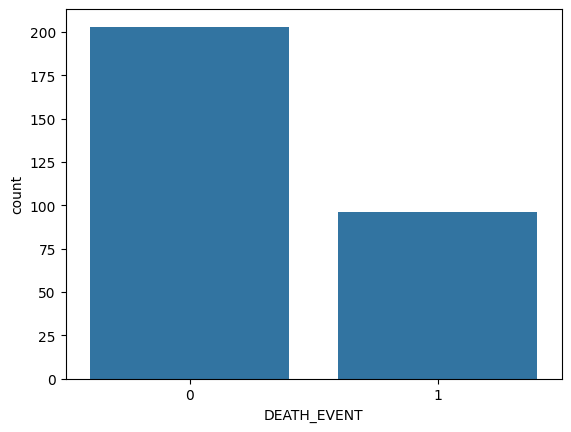

In [8]:
sns.countplot(x="DEATH_EVENT",data=data)

<Axes: ylabel='count'>

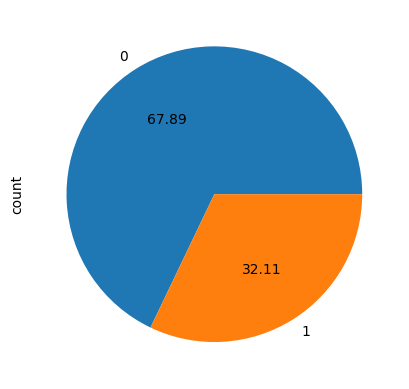

In [9]:
y.value_counts().plot.pie(autopct='%.2f')
#plot.pie this is in pandas

In [10]:
! pip install -U imbalanced-learn

## **now to solve this problem we will use 1) undersampling**

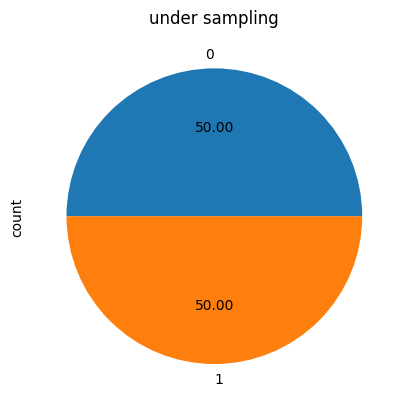

In [11]:
from imblearn.under_sampling import RandomUnderSampler
rus=RandomUnderSampler(sampling_strategy=1)
x_rus,y_rus=rus.fit_resample(x,y)

ax= y_rus.value_counts().plot.pie(autopct='%.2f')
_=ax.set_title("under sampling")

In [12]:
y_rus.value_counts()


,count
DEATH_EVENT,
0,96
1,96


In [13]:
x_rus.info()

<class 'pandas.core.frame.DataFrame'>
Index: 192 entries, 249 to 266
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       192 non-null    float64
 1   anaemia                   192 non-null    int64  
 2   creatinine_phosphokinase  192 non-null    int64  
 3   diabetes                  192 non-null    int64  
 4   ejection_fraction         192 non-null    int64  
 5   high_blood_pressure       192 non-null    int64  
 6   platelets                 192 non-null    float64
 7   serum_creatinine          192 non-null    float64
 8   serum_sodium              192 non-null    int64  
 9   sex                       192 non-null    int64  
 10  smoking                   192 non-null    int64  
 11  time                      192 non-null    int64  
dtypes: float64(3), int64(9)
memory usage: 19.5 KB


In [29]:
x_rus.to_csv("x_rus.csv",index=False)
y_rus.to_csv("y_rus.csv",index=False)

## **now to solve this problem we will use 2) oversampling**

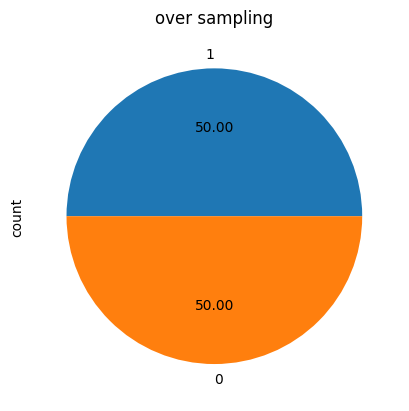

In [17]:
from imblearn.over_sampling import RandomOverSampler
ros= RandomOverSampler(sampling_strategy=1)
x_ros,y_ros=ros.fit_resample(x,y)
ax=y_ros.value_counts().plot.pie(autopct='%.2f')
_=ax.set_title("over sampling")


In [18]:
y_ros.value_counts()

,count
DEATH_EVENT,
1,203
0,203


In [22]:
y_ros.duplicated().sum()

np.int64(404)

In [30]:
x_ros.to_csv("x_ros.csv",index=False)
y_ros.to_csv("y_ros.csv",index=False)

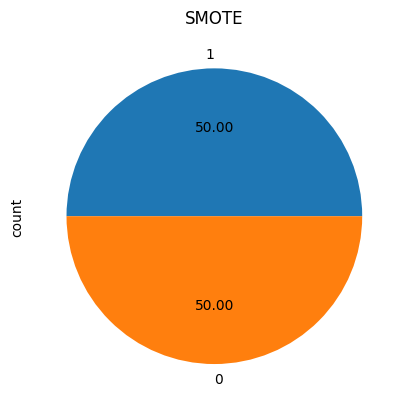

In [23]:
from imblearn.over_sampling import SMOTE
smt=SMOTE()
x_smt,y_smt=smt.fit_resample(x,y)
ax=y_smt.value_counts().plot.pie(autopct='%.2f')
_=ax.set_title("SMOTE")

In [24]:
y_smt.value_counts()

,count
DEATH_EVENT,
1,203
0,203


In [25]:
y_smt.duplicated().sum()

np.int64(404)

In [31]:
x_smt.to_csv("x_smt.csv",index=False)
y_smt.to_csv("y_smt.csv",index=False)

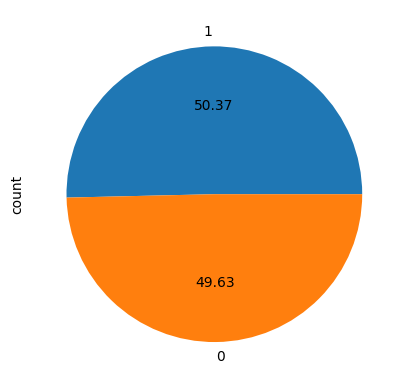

In [26]:
from imblearn.over_sampling import ADASYN
ada=ADASYN(random_state=130)
x_ada,y_ada=ada.fit_resample(x,y)
ax=y_ada.value_counts().plot.pie(autopct='%.2f')

In [27]:
y_ada.duplicated().sum()

np.int64(407)

In [32]:
x_ada.to_csv("x_ada.csv",index=False)
y_ada.to_csv("y_ada.csv",index=False)